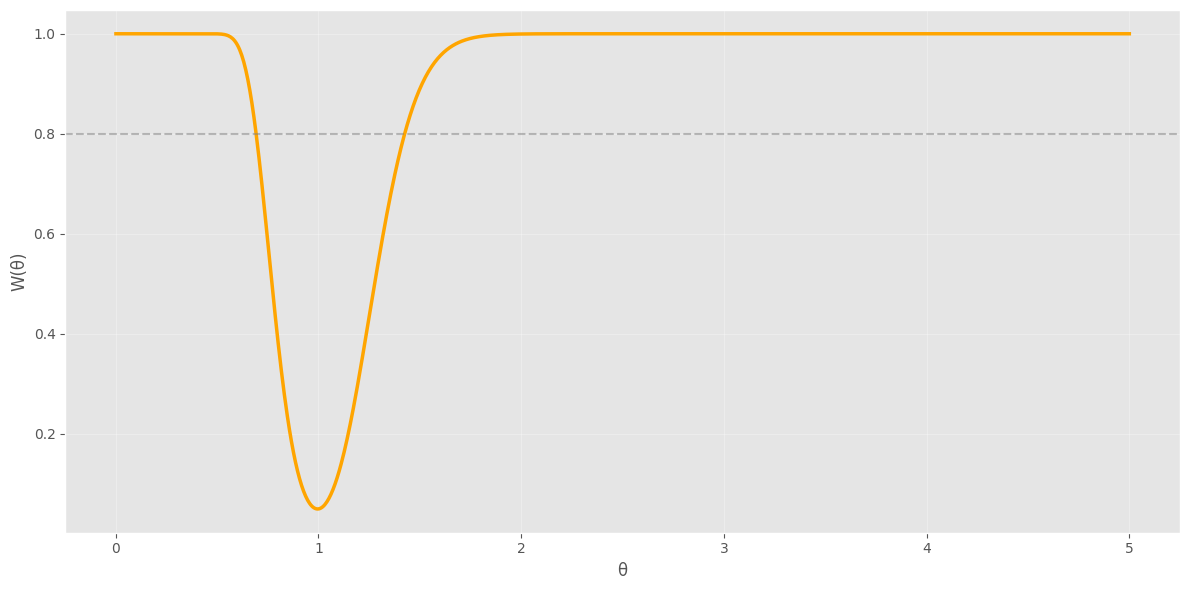

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
import scipy.optimize as opt
import seaborn as sns
import math as mt
from skimage.io import imread, imsave

np.random.seed(52)
plt.style.use('ggplot')

def calc_sample_variance(std_value, sample_size):
    return sample_size / (sample_size - 1) * std_value ** 2


significance_level = 0.05
std_head_egypt = 5.722
std_ear_egypt = 4.612
std_head_europe = 6.161
std_ear_europe = 5.055
sample_egypt = 139
sample_europe = 1000


var_head_egypt = calc_sample_variance(std_head_egypt, sample_egypt)
var_ear_egypt = calc_sample_variance(std_ear_egypt, sample_egypt)
var_head_europe = calc_sample_variance(std_head_europe, sample_europe)
var_ear_europe = calc_sample_variance(std_ear_europe, sample_europe)

f_stat_head = var_head_egypt / var_head_europe
f_stat_ear = var_ear_egypt / var_ear_europe


df1 = sample_egypt - 1
df2 = sample_europe - 1
crit_low = stats.f.ppf(significance_level / 2, df1, df2)
crit_high = stats.f.ppf(1 - significance_level / 2, df1, df2)

fig, power_plot = plt.subplots(1, 1, figsize=(12, 6))


theta_range = np.linspace(0.001, 5, 1000)
power_vals = 1 - stats.f.cdf(crit_high, df1, df2, scale=theta_range) + \
                 stats.f.cdf(crit_low, df1, df2, scale=theta_range)


power_plot.plot(theta_range, power_vals, color='orange', linewidth=2.5)
power_plot.set_xlabel("θ", fontsize=12)
power_plot.set_ylabel("W(θ)", fontsize=12)
power_plot.grid(True, alpha=0.3)

power_plot.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
